In [1]:
import scanpy as sc
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

import numpy as np

palette = {'wt': 'blue', 'mutated': 'red', 'heterozygous': 'orange'}

import matplotlib.colors as mcolors


In [2]:
adata = sc.read_h5ad('../output/gapfill_betaine_1plex_genotyped_adata.h5ad')
adata.obsm['predicted_genotypes'] = adata.obsm['predicted_genotypes'].replace({0: 'wt', 1: 'mutated', 2: 'heterozygous'}).astype(object).copy()
adata.obsm['genotypes'] = adata.obsm['genotypes'].replace({0: 'wt', 1: 'mutated', 2: 'heterozygous'}).astype(object).copy()

adata = adata[adata.obs['BC'] == 'CL3_HB_Betaine_BC001'].copy() ## subset to the gapfill barcode (others have dual probes)

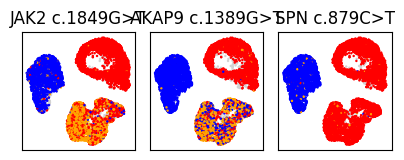

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(4, 1.7))
for i, probe in enumerate(['JAK2 c.1849G>T','AKAP9 c.1389G>T','SPN c.879C>T']):
    adata.obs['temp'] = adata.obsm['genotypes'][probe].copy()
    BC_to_keep = adata[adata.obs['temp'].notna()].obs['BC'].unique()[0]
    sc.pl.umap(
        adata[adata.obs['BC'] == BC_to_keep].copy(),
        color='temp',
        frameon=True,
        title=probe,
        palette=palette,
        ax=axs[i],
        show=False,
        legend_loc='right margin' if i == 3 else None
    )
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
plt.tight_layout()

plt.savefig('../plots/UMAP_genotyping_gapfill.pdf', bbox_inches='tight')

JAK2 c.1849G>T 0.8554005167958656
AKAP9 c.1389G>T 0.8561240310077519
SPN c.879C>T 0.9674418604651163


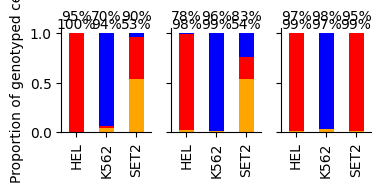

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(4, 2), sharey=True)
for i, probe in enumerate(['JAK2 c.1849G>T','AKAP9 c.1389G>T','SPN c.879C>T']):
    adata.obs['temp'] = adata.obsm['genotypes'][probe].copy()
    proportions = adata.obs.groupby('cell_type', observed=False)['temp'].value_counts(normalize=True).unstack().fillna(0)
    if 'mutated' in proportions.columns:
        proportions = proportions.sort_values(['mutated'])
    colors = ['orange', 'red', 'blue']
    expected_columns = ['heterozygous', 'mutated', 'wt']
    available_columns = [col for col in expected_columns if col in proportions.columns]
    proportions = proportions[available_columns]
    proportions = proportions.reindex(labels=['HEL','K562','SET2']).copy()
    colors = [colors[expected_columns.index(col)] for col in available_columns]
    proportions.plot(kind='bar', stacked=True, ax=axs[i], color=colors)
    axs[i].set_xlabel('Cell Type')
    axs[i].set_ylabel('Proportion of genotyped cells')
    axs[i].get_legend().remove()
    # Add count of cells genotyped above each bar
    for j, cell_type in enumerate(proportions.index):
        count = adata.obs[adata.obs['cell_type'] == cell_type]['temp'].notna().sum()
        total_cells = adata.obs[adata.obs['cell_type'] == cell_type].shape[0]
        proportion_genotyped = count / total_cells
        prop_correct = (adata[(adata.obs['cell_type'] == cell_type) & (adata.obs['temp'].notna())].obsm['genotypes'][probe] == adata[(adata.obs['cell_type'] == cell_type) & (adata.obs['temp'].notna())].obsm['predicted_genotypes'][probe]).value_counts(normalize=True)[True]
        axs[i].text(j, 1.02, f'{prop_correct:.0%}', ha='center', va='bottom', fontsize=10)
        axs[i].text(j, 1.10, f'{proportion_genotyped:.0%}', ha='center', va='bottom', fontsize=10)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['top'].set_visible(False)
    axs[i].set_xlabel('')
    if i > 0:
        axs[i].set_ylabel('')
    print(probe, adata.obs['temp'].notna().mean()) ## print proportion of cells genotyped for each probe
plt.tight_layout()

plt.savefig('../plots/stacked_bars_genotyping_gapfill.pdf', bbox_inches='tight')